# Clasificación de Imágenes con Redes Neuronales Preentrenadas (ResNet18)

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Asignatura Ministerial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de esta sesión es familiarizarnos con el uso de **modelos preentrenados** de visión artificial profunda. Cargaremos y utilizaremos la arquitectura de referencia **ResNet18** (entrenada en ImageNet) dentro del ecosistema de PyTorch para realizar clasificación de imágenes del mundo real sin necesidad de entrenar un modelo desde cero.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Explicar el concepto y las ventajas del uso de modelos preentrenados en Procesamiento Digital de Imágenes.
2. Cargar y configurar la arquitectura residual `ResNet18` en PyTorch empleando pesos preentrenados oficiales de `torchvision`.
3. Diseñar y aplicar el pipeline de preprocesamiento de tensores (redimensionado, recorte central, conversión a tensores y normalización estándar) requerido por los modelos de ImageNet.
4. Ejecutar flujos de inferencia libre de cálculo de gradientes y decodificar las predicciones top-5 más altas de un clasificador generalista.

## Terminología clave (Microglosario)

*   **Modelo Preentrenado:** Red neuronal cuyos pesos ya han sido optimizados en un conjunto de datos masivo. Esto nos permite aprovechar sus filtros jerárquicos de detección de formas, bordes y texturas sin gastar tiempo en un entrenamiento desde cero.
*   **ResNet18 (Red Residual):** Arquitectura de red neuronal convolucional caracterizada por poseer conexiones residuales (*shortcut connections*), las cuales mitigan el problema de desvanecimiento del gradiente al permitir que la información saltee ciertas capas. ResNet18 es una arquitectura de red neuronal convolucional (CNN) para clasificación de imágenes, parte de la familia ResNet (Residual Networks), publicada por Microsoft Research en 2015. El "18" indica: 18 capas con pesos entrenables.
*   **ImageNet:** Dataset de referencia estándar en visión artificial que cuenta con más de 14 millones de imágenes clasificadas de forma manual en 1000 categorías de objetos comunes.
*   **Normalización Espacial:** Ajuste numérico aplicado a los píxeles de una imagen para que su media y desviación estándar coincidan con las estadísticas del conjunto de entrenamiento original de ImageNet, garantizando la consistencia del modelo.
*   **PyTorch:** es un framework de deep learning desarrollado por Meta (Facebook). Es una de las bibliotecas más populares para construir y entrenar redes neuronales, muy usada tanto en investigación como en producción.

## 1. Configuración de Librerías y Dependencias

Carguemos las herramientas esenciales de PyTorch, torchvision, solicitudes de red y visualización gráfica.

In [1]:
# Verificamos las dependencias del kernel sin instalar ni modificar paquetes.
from importlib.metadata import version

print('✓ Kernel especializado: Python 3.12 (PyTorch - ResNet18)')
for paquete in ('torch', 'torchvision', 'matplotlib', 'requests', 'pillow'):
    print(f'{paquete}: {version(paquete)}')

✓ Kernel especializado: Python 3.12 (PyTorch - ResNet18)
torch: 2.12.1
torchvision: 0.27.1
matplotlib: 3.11.0
requests: 2.34.2
pillow: 12.2.0


In [ ]:
# Este bloque importa las bibliotecas que se usaran mas adelante; centralizar las importaciones 
# deja claro que herramientas participan: manejo de datos, visualizacion, redes neuronales, 
# imagenes o despliegue.
print('✦ Cargando librerías y configurando entorno de Deep Learning...')  # Muestra informacion en consola para verificar el avance o los resultados.
import torch  # Importa torch para usar sus funciones en el notebook.
from torchvision import models, transforms  # Importa componentes especificos desde torchvision.
from PIL import Image  # Importa componentes especificos desde PIL.
import requests  # Importa requests para usar sus funciones en el notebook.
import matplotlib.pyplot as plt  # Importa matplotlib para usar sus funciones en el notebook.
print('✓ Entorno listo para operar.\n')  # Muestra informacion en consola para verificar el avance o los resultados.

print('✦ Descargando y cargando ResNet18 preentrenado con ImageNet...')  # Muestra informacion en consola para verificar el avance o los resultados.
# Cargamos el modelo utilizando la constante oficial de pesos por defecto
modelo = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)  # Calcula y guarda el valor en la variable modelo.
# Configuramos el modelo en modo de evaluación (desactiva capas de dropout y batch normalization)
modelo.eval()  # Completa una llamada o estructura iniciada en lineas anteriores.
print('✓ Modelo cargado correctamente en modo de evaluación.')  # Muestra informacion en consola para verificar el avance o los resultados.

✦ Cargando librerías y configurando entorno de Deep Learning...
✓ Entorno listo para operar.

✦ Descargando y cargando ResNet18 preentrenado con ImageNet...
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\carme/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


✓ Modelo cargado correctamente en modo de evaluación.


## 2. Definición del Pipeline de Preprocesamiento

Para que la red ResNet18 procese la imagen correctamente, debemos adecuar sus dimensiones y estadísticas numéricas al mismo formato con el que fue entrenada originalmente en ImageNet ($224 \times 224$ píxeles con normalización estándar de canal).

In [ ]:
# Comentario general: este bloque preprocesa los datos para que tengan escala y forma adecuadas; 
# las redes neuronales trabajan mejor cuando las entradas son numericas, consistentes y comparables entre si.
# Definimos el pipeline de transformaciones secuenciales en PyTorch
preprocesado = transforms.Compose([  # Calcula y guarda el valor en la variable preprocesado.
    # Redimensionamos la imagen de forma que el lado menor mida 256 píxeles
    transforms.Resize(256),  # Redimensiona la imagen al tamano esperado por el modelo.
    # Recortamos una sección cuadrada de 224x224 en el centro de la imagen
    transforms.CenterCrop(224),  # Ejecuta esta instruccion como parte del flujo principal del notebook.
    # Convertimos la imagen de formato PIL a un tensor de PyTorch, escalando los valores al rango [0, 1]
    transforms.ToTensor(),  # Ejecuta esta instruccion como parte del flujo principal del notebook.
    # Normalizamos el tensor utilizando la media y desviación estándar exactas de ImageNet
    transforms.Normalize(  # Ejecuta esta instruccion como parte del flujo principal del notebook.
        mean=[0.485, 0.456, 0.406],  # Calcula y guarda el valor en la variable mean.
        std=[0.229, 0.224, 0.225]  # Calcula y guarda el valor en la variable std.
    )  # Completa una llamada o estructura iniciada en lineas anteriores.
])  # Completa una llamada o estructura iniciada en lineas anteriores.

## 3. Descarga y Visualización de la Imagen de Prueba

Descargaremos una imagen real de internet para testear nuestro clasificador y aplicaremos las transformaciones de preprocesamiento.

✦ Descargando imagen de prueba desde internet...
✓ Imagen obtenida con éxito.



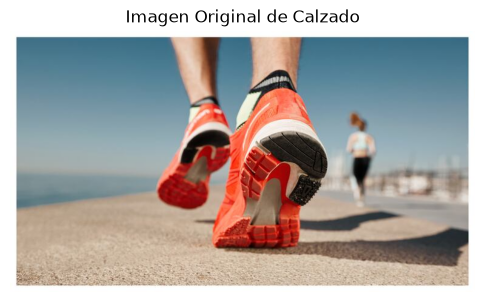

✓ Imagen preprocesada y convertida a tensor compatible.


In [ ]:
# Descargamos una imagen real desde internet para probar el modelo con datos externos
# (no del dataset de entrenamiento), lo que permite evaluar su capacidad de generalización.
url_imagen = 'https://tn.com.ar/resizer/v2/cometer-este-error-al-elegir-zapatillas-para-correr-puede-costarte-caro-foto-freepik-TPFZRN3T35DLJP25JEO7B3TTCQ.jpg?auth=29f5ab2a4aa0d60dff5a403137a8acce97a300ef00dae6c4f900b815b9b279fb&width=767'

try:
    print('✦ Descargando imagen de prueba desde internet...')
    respuesta = requests.get(url_imagen, stream=True, timeout=15)  # stream=True evita cargar todo el contenido en memoria antes de procesarlo.
    imagen = Image.open(respuesta.raw)  # Decodifica los bytes de la respuesta HTTP como imagen PIL, formato que acepta el preprocesado.
    print('✓ Imagen obtenida con éxito.\n')
    
    # Mostramos la imagen antes del preprocesado para verificar visualmente que se descargó correctamente
    # y para poder comparar luego con las transformaciones que aplica el pipeline.
    plt.figure(figsize=(6, 6))
    plt.imshow(imagen)
    plt.title('Imagen Original de Calzado')
    plt.axis('off')  # Ocultamos los ejes porque no aportan información útil para una imagen.
    plt.show()
    
    # Aplicamos las mismas transformaciones usadas durante el entrenamiento de ResNet18
    # (resize, normalización, etc.) para que el tensor tenga el formato esperado por el modelo.
    # unsqueeze(0) agrega la dimensión de lote: el modelo espera (batch, canales, alto, ancho).
    input_tensor = preprocesado(imagen).unsqueeze(0)
    print('✓ Imagen preprocesada y convertida a tensor compatible.')
except Exception as e:  # Capturamos cualquier fallo de red o de decodificación para no interrumpir el notebook.
    print(f'✗ Error al descargar o preprocesar la imagen: {e}')


## 4. Inferencia y Clasificación en ImageNet

Descargaremos el mapeo oficial de las 1000 categorías de ImageNet, pasaremos la imagen por la red ResNet18 y decodificaremos las 5 categorías más probables asignadas por el modelo.

In [ ]:
# Este bloque ejecuta la inferencia sobre la imagen descargada y traduce la salida numérica
# del modelo a etiquetas legibles, mostrando las 5 categorías con mayor probabilidad asignada.

# Necesitamos las etiquetas para traducir los índices de salida del modelo (0-999) a nombres de clase.
url_etiquetas = 'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt'

try:
    print('✦ Descargando etiquetas oficiales de ImageNet...')
    respuesta_etiquetas = requests.get(url_etiquetas, timeout=15)
    etiquetas = respuesta_etiquetas.text.split('\n')  # Cada línea es una clase; el índice coincide con la posición de salida del modelo.
    print(f'✓ {len(etiquetas)} categorías listas para clasificar.\n')

    print('✦ Ejecutando inferencia con la red ResNet18...')
    # Desactivamos gradientes porque solo estamos haciendo predicción, no entrenando;
    # esto reduce el uso de memoria y acelera el cómputo.
    with torch.no_grad():
        salida = modelo(input_tensor)  # El modelo devuelve 1000 valores (logits), uno por clase de ImageNet.

    # Softmax convierte los logits en probabilidades que suman 1,
    # lo que permite interpretarlos como porcentajes de confianza.
    probabilidades = torch.nn.functional.softmax(salida[0], dim=0)
    
    # Top-5 es la métrica estándar en ImageNet: mostramos las 5 clases más probables
    # porque para imágenes ambiguas la clase correcta no siempre queda en primer lugar.
    valores_top, indices_top = torch.topk(probabilidades, 5)
    
    print('Resultados de Clasificación del Modelo (Top 5):')
    for i in range(5):
        nombre_clase = etiquetas[indices_top[i]]
        porcentaje = valores_top[i].item() * 100  # .item() extrae el escalar del tensor para poder operar con él como float.
        print(f'  ❖ {i+1}. {nombre_clase}: {porcentaje:.2f}%')

except Exception as e:  # Capturamos fallos de red y errores de inferencia para no interrumpir el notebook.
    print(f'✗ Error durante la inferencia o decodificación: {e}')


✦ Descargando etiquetas oficiales de ImageNet...
✓ 1000 categorías listas para clasificar.

✦ Ejecutando inferencia con la red ResNet18...
Resultados de Clasificación del Modelo (Top 5):
  ❖ 1. sock: 52.54%
  ❖ 2. knee pad: 7.58%
  ❖ 3. clog: 6.36%
  ❖ 4. cowboy boot: 4.18%
  ❖ 5. running shoe: 4.00%


## Consigna de Lectura e Interpretación

Revisen los resultados impresos de las predicciones del modelo.  

**Cuál fue el objeto con mayor porcentaje de probabilidad asignado por la red? Compárenlo con el calzado que se observa en la imagen original de prueba.**
La clase con mayor probabilidad fue **“sock” (media), con 52,54 %**. Sin embargo, el objeto principal de la imagen es un par de zapatillas deportivas. El modelo probablemente se concentró en rasgos visuales similares a una media, como la zona negra que rodea el tobillo, y no interpretó correctamente el calzado completo.

**¿Qué ventajas identifican en utilizar un modelo que ya posee este conocimiento preentrenado?**
La ventaja de utilizar ResNet18 preentrenada es que ya reconoce patrones generales —formas, bordes, colores y texturas—, por lo que permite obtener resultados rápidamente y requiere menos datos y tiempo de entrenamiento. No obstante, sus categorías de ImageNet pueden no ajustarse exactamente a la tarea; por eso sería conveniente aplicar *fine-tuning* con imágenes específicas de calzado.

## Cierre de Laboratorio

Han comprobado de forma práctica la potencia y simplicidad que brinda utilizar un modelo del estado del arte preentrenado de visión artificial como **ResNet18**.

En la siguiente sesión daremos un paso sumamente importante: utilizaremos la técnica de **Transferencia de Aprendizaje (Transfer Learning)** para congelar este conocimiento base y re-entrenar las capas finales en un conjunto de imágenes personalizado.